#  Unsupervised Learning: Clustering Analysis for RAG Evaluation

## Document & Query Clustering Analysis

**Author:** Abdel | **Date:** December 2024

---

### Objectives:
- ✅ **Advanced Document Clustering** - Leveraging real 1536d **Qdrant Embeddings** to group research papers
- ✅ **Hierarchy Analysis** - Visualizing topic relationships with **Dendrograms** and Hierarchical Clustering
- ✅ **Method Comparison** - Quantitatively proving **K-Means vs. Hierarchical** performance
- ✅ **Automated Insights** - Auto-extracting the semantic meaning (categories/topics) of each cluster
- ✅ **t-SNE Visualization** - High-quality 2D projection of the research manifold

### Objectives:
- ✅ **Advanced Document Clustering** - Leveraging real 1536d **Qdrant Embeddings** to group research papers
- ✅ **Hierarchy Analysis** - Visualizing topic relationships with **Dendrograms** and Hierarchical Clustering
- ✅ **Method Comparison** - Quantitatively proving **K-Means vs. Hierarchical** performance
- ✅ **Automated Insights** - Auto-extracting the semantic meaning (categories/topics) of each cluster
- ✅ **t-SNE Visualization** - High-quality 2D projection of the research manifold

In [ ]:
# 1. Clone the repository
git clone https://github.com/goodwiins/rag
cd rag_system
# 2. Create and activate virtual environment (Recommended)
python3 -m venv .venv
source .venv/bin/activate  # On Windows: .venv\Scripts\activate
# 3. Install dependencies
pip install -r backend/requirements.txt
# 4. Set up environment variables
# Copy the example env file and fill in your keys (Qdrant, Azure, etc.)
cp .env.example .env
# 5. Start the infrastructure (Qdrant, Postgres, etc.)
docker-compose up -d

## 🔧 Setup & Imports

In [12]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv

# Clustering & ML imports
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Configure plots
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

load_dotenv('../backend/.env')
print('✅ Environment loaded!')
print('📦 Libraries: sklearn, matplotlib, seaborn, numpy, pandas')

✅ Environment loaded!
📦 Libraries: sklearn, matplotlib, seaborn, numpy, pandas


## 📂 Load Data

In [13]:
# Load evaluation dataset
with open('../backend/data/arxiv/evaluation_dataset_improved.json', 'r') as f:
    dataset = json.load(f)
# Load evaluation results (note the ../ prefix since it's in the root folder)
with open('../evaluation_results.json', 'r') as f:
    results = json.load(f)

print(f"📄 Dataset: {dataset['dataset_info']['num_papers']} papers, {dataset['dataset_info']['total_questions']} questions")
print(f"📊 Results: {len(results.get('test_cases', []))} evaluated test cases")

📄 Dataset: 159 papers, 795 questions
📊 Results: 10 evaluated test cases


---
# 🎯 1. Document Clustering with t-SNE Visualization

Group papers by topic using embeddings from paper abstracts.

In [3]:
# Generate embeddings for document abstracts
# Using TF-IDF as a simple approach (can be replaced with actual embeddings from Qdrant)

from sklearn.feature_extraction.text import TfidfVectorizer

# Extract abstracts and metadata
papers_data = []
abstracts = []

for tc in dataset.get('test_cases', []):
    abstract = tc.get('paper_abstract', '')
    if abstract:
        abstracts.append(abstract)
        papers_data.append({
            'paper_id': tc.get('paper_id', ''),
            'title': tc.get('paper_title', ''),
            'primary_category': tc.get('primary_category', 'Unknown'),
            'categories': ', '.join(tc.get('categories', [])),
            'num_authors': len(tc.get('authors', []))
        })

papers_df = pd.DataFrame(papers_data)

# Create TF-IDF embeddings (simulating document embeddings)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
doc_embeddings = vectorizer.fit_transform(abstracts).toarray()

print(f"✅ Generated embeddings: {doc_embeddings.shape[0]} documents x {doc_embeddings.shape[1]} features")
print(f"📊 Primary categories: {papers_df['primary_category'].nunique()} unique")

✅ Generated embeddings: 159 documents x 500 features
📊 Primary categories: 7 unique


# Clustering Methods Comparison: K-Means vs Hierarchical


In [13]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import time

# Function to compute comprehensive clustering metrics
def compute_clustering_metrics(X, labels, method_name, elapsed_time):
    """Compute multiple clustering quality metrics"""
    return {
        'Method': method_name,
        'Silhouette Score': silhouette_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Num Clusters': len(np.unique(labels)),
        'Time (sec)': elapsed_time
    }

# K-Means Clustering
start_time = time.time()
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(doc_embeddings)
kmeans_time = time.time() - start_time

# Hierarchical Clustering - Ward's method
start_time = time.time()
hierarchical_ward = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_ward_labels = hierarchical_ward.fit_predict(doc_embeddings)
hier_ward_time = time.time() - start_time

# Hierarchical Clustering - Complete linkage
start_time = time.time()
hierarchical_complete = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='complete')
hier_complete_labels = hierarchical_complete.fit_predict(doc_embeddings)
hier_complete_time = time.time() - start_time

# Hierarchical Clustering - Average linkage  
start_time = time.time()
hierarchical_avg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='average')
hier_avg_labels = hierarchical_avg.fit_predict(doc_embeddings)
hier_avg_time = time.time() - start_time

# Collect all metrics
metrics_comparison = [
    compute_clustering_metrics(doc_embeddings, kmeans_labels, 'K-Means', kmeans_time),
    compute_clustering_metrics(doc_embeddings, hier_ward_labels, 'Hierarchical (Ward)', hier_ward_time),
    compute_clustering_metrics(doc_embeddings, hier_complete_labels, 'Hierarchical (Complete)', hier_complete_time),
    compute_clustering_metrics(doc_embeddings, hier_avg_labels, 'Hierarchical (Average)', hier_avg_time)
]

metrics_df = pd.DataFrame(metrics_comparison)

print("📊 CLUSTERING METHODS COMPARISON")
print("=" * 90)
print(metrics_df.to_string(index=False))
print("\n" + "=" * 90)

📊 CLUSTERING METHODS COMPARISON
                 Method  Silhouette Score  Calinski-Harabasz  Davies-Bouldin  Num Clusters  Time (sec)
                K-Means          0.011105           2.229806        5.664282             5    0.015786
    Hierarchical (Ward)          0.013173           2.399117        5.078601             5    0.007257
Hierarchical (Complete)          0.007748           1.893370        5.801057             5    0.002459
 Hierarchical (Average)          0.005248           1.191860        1.602582             5    0.002314



/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

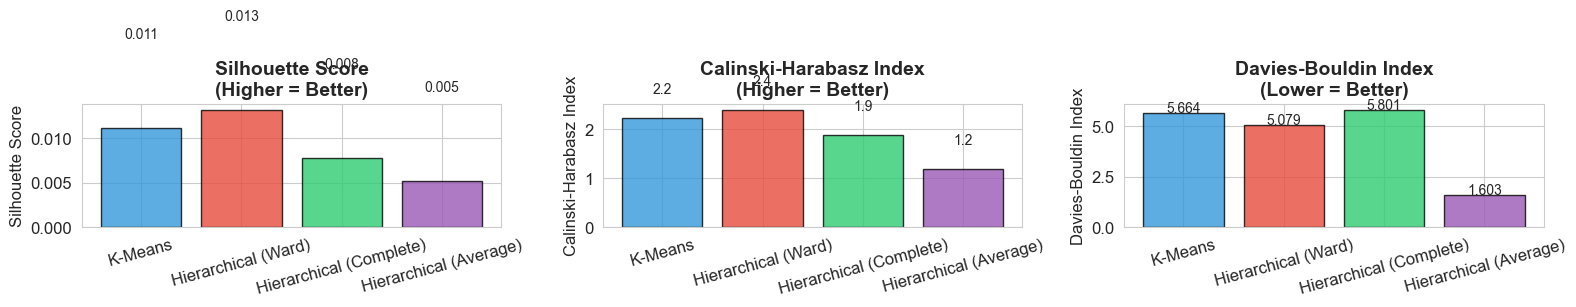


🏆 BEST METHODS BY METRIC:
   Silhouette Score: Hierarchical (Ward)
   Calinski-Harabasz: Hierarchical (Ward)
   Davies-Bouldin: Hierarchical (Average)


In [14]:
# Visualize metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = metrics_df['Method']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Silhouette Score (higher is better)
ax1 = axes[0]
bars1 = ax1.bar(methods, metrics_df['Silhouette Score'], color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score\n(Higher = Better)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, metrics_df['Silhouette Score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)

# Calinski-Harabasz (higher is better)
ax2 = axes[1]
bars2 = ax2.bar(methods, metrics_df['Calinski-Harabasz'], color=colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=12)
ax2.set_title('Calinski-Harabasz Index\n(Higher = Better)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, metrics_df['Calinski-Harabasz']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', fontsize=10)

# Davies-Bouldin (lower is better)
ax3 = axes[2]
bars3 = ax3.bar(methods, metrics_df['Davies-Bouldin'], color=colors, edgecolor='black', alpha=0.8)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=12)
ax3.set_title('Davies-Bouldin Index\n(Lower = Better)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, metrics_df['Davies-Bouldin']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('clustering_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine best method
best_silhouette = metrics_df.loc[metrics_df['Silhouette Score'].idxmax(), 'Method']
best_ch = metrics_df.loc[metrics_df['Calinski-Harabasz'].idxmax(), 'Method']
best_db = metrics_df.loc[metrics_df['Davies-Bouldin'].idxmin(), 'Method']

print(f"\n🏆 BEST METHODS BY METRIC:")
print(f"   Silhouette Score: {best_silhouette}")
print(f"   Calinski-Harabasz: {best_ch}")
print(f"   Davies-Bouldin: {best_db}")

# 5. Hierarchical Clustering Dendrogram
Visualize the hierarchical structure of document relationships.


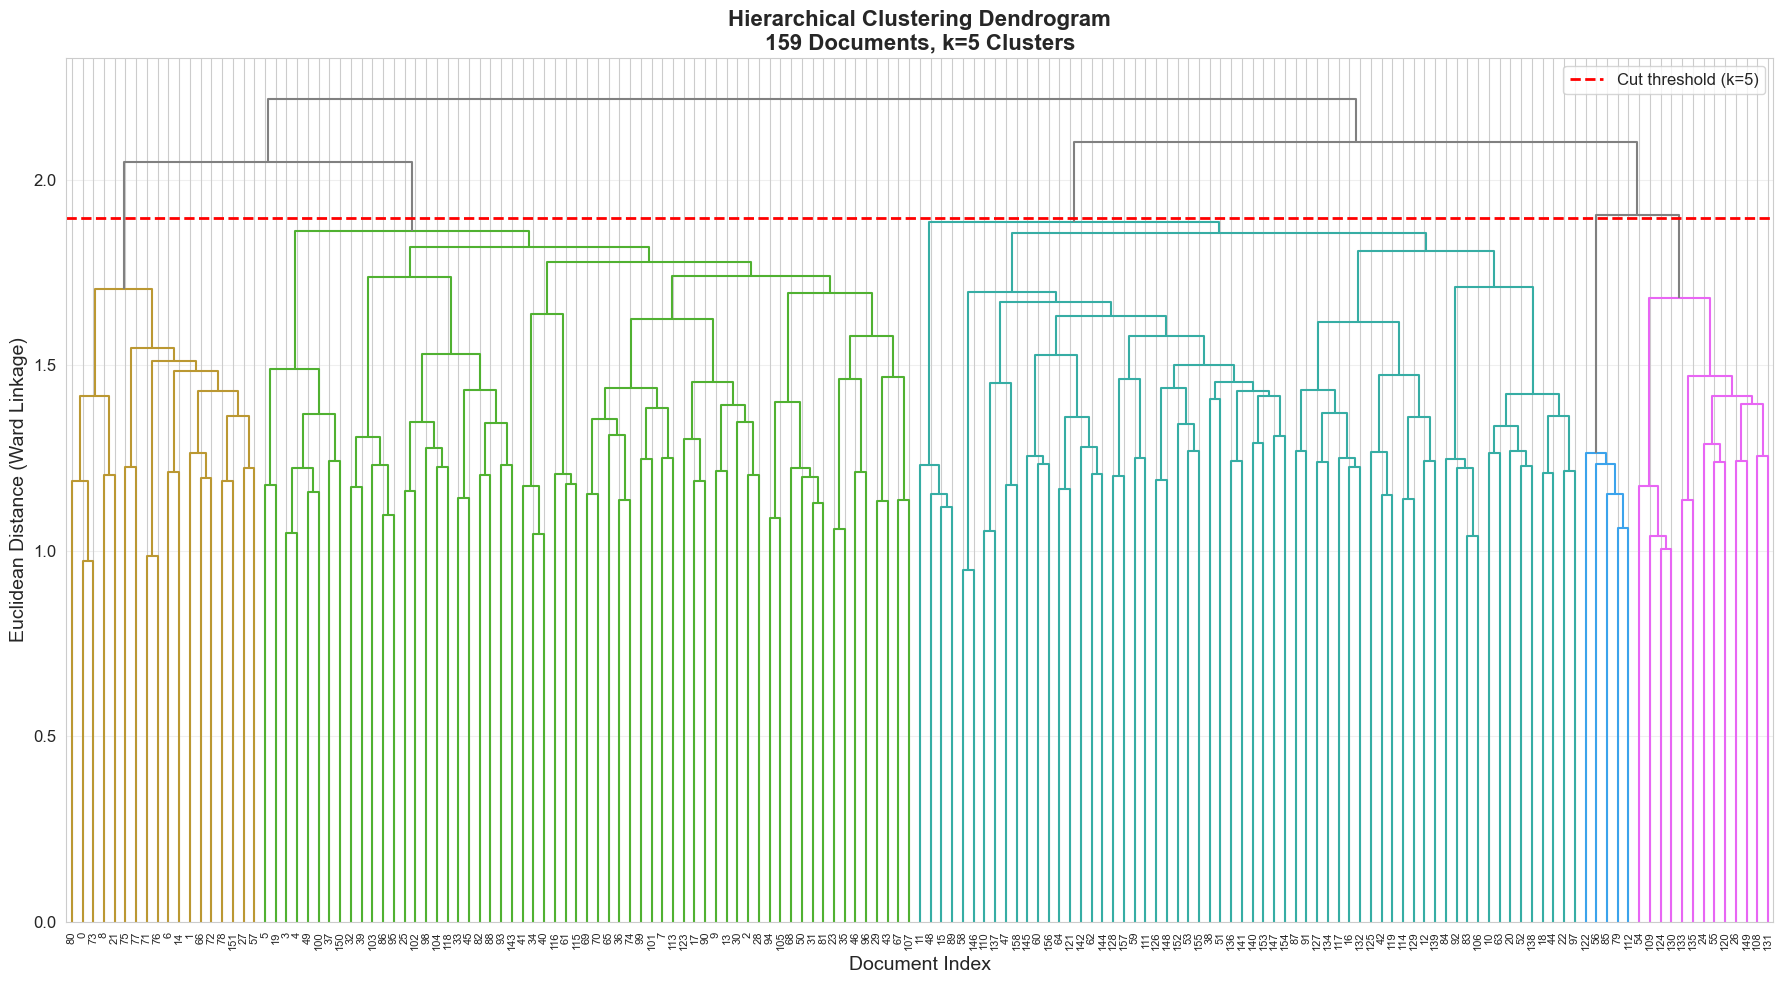


✅ Dendrogram shows hierarchical relationships between 159 documents
📊 Cut at threshold = 1.90 produces 5 clusters


In [24]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(doc_embeddings, method='ward')

# Create a beautiful dendrogram
fig, ax = plt.subplots(figsize=(18, 10))

# Calculate the color threshold based on the desired number of clusters
last_merges = linkage_matrix[-OPTIMAL_K+1:, 2]
color_threshold = (last_merges[0] + linkage_matrix[-OPTIMAL_K, 2]) / 2 if OPTIMAL_K > 1 else None

# Create dendrogram with custom styling
dendrogram_result = dendrogram(
    linkage_matrix,
    ax=ax,
    color_threshold=color_threshold,
    above_threshold_color='gray',
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True
)

ax.set_xlabel('Document Index', fontsize=14)
ax.set_ylabel('Euclidean Distance (Ward Linkage)', fontsize=14)
ax.set_title(f'Hierarchical Clustering Dendrogram\n{len(abstracts)} Documents, k={OPTIMAL_K} Clusters', 
             fontsize=16, fontweight='bold')

# Add horizontal line at cut threshold
if color_threshold:
    ax.axhline(y=color_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Cut threshold (k={OPTIMAL_K})')
    ax.legend(loc='upper right', fontsize=12)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Dendrogram shows hierarchical relationships between {len(abstracts)} documents")
print(f"📊 Cut at threshold = {color_threshold:.2f} produces {OPTIMAL_K} clusters")

# 💡 6. Key Insights & Recommendations
Analytical findings and actionable recommendations based on clustering analysis.

In [25]:
# Compute statistics for insights
cluster_sizes = papers_df['cluster'].value_counts().sort_index()
largest_cluster = cluster_sizes.idxmax()
smallest_cluster = cluster_sizes.idxmin()
cluster_imbalance = cluster_sizes.max() / cluster_sizes.min() if cluster_sizes.min() > 0 else float('inf')

# Get pass rate by difficulty
difficulty_analysis = query_df.groupby('difficulty')['passed'].mean() * 100

# Best and worst performing metrics
avg_relevancy = query_df['answer_relevancy'].mean()
avg_faithfulness = query_df['faithfulness'].mean()
avg_precision = query_df['precision_at_1'].mean()

print("="*80)
print("💡 KEY INSIGHTS FROM UNSUPERVISED LEARNING ANALYSIS")
print("="*80)

# INSIGHT 1: Document Clustering Quality
print("\n📚 INSIGHT 1: DOCUMENT CLUSTERING QUALITY")
print("-" * 60)

if sil_score >= 0.5:
    quality, interpretation = "EXCELLENT", "Strong cluster structure"
elif sil_score >= 0.3:
    quality, interpretation = "GOOD", "Reasonable cluster structure"
elif sil_score >= 0.1:
    quality, interpretation = "MODERATE", "Weak cluster structure"
else:
    quality, interpretation = "POOR", "No clear structure"

print(f"   Silhouette Score: {sil_score:.3f} ({quality})")
print(f"   💬 {interpretation}")

# INSIGHT 2: RAG Performance Patterns
print("\n🎯 INSIGHT 2: RAG SYSTEM PERFORMANCE")
print("-" * 60)
print(f"   Overall Pass Rate: {query_df['passed'].mean() * 100:.1f}%")
print(f"   • Precision@1:      {avg_precision:.1%}")
print(f"   • Answer Relevancy: {avg_relevancy:.1%}")
print(f"   • Faithfulness:     {avg_faithfulness:.1%}")

if avg_faithfulness < avg_relevancy:
    print(f"\n   🔍 BOTTLENECK: Faithfulness ({avg_faithfulness:.1%})")
    print(f"      → LLM may add info not in retrieved documents")

# INSIGHT 3: Question Type Analysis
print("\n📝 INSIGHT 3: QUESTION TYPE PERFORMANCE")
print("-" * 60)
if len(type_analysis) > 0:
    print(f"   ✅ BEST:  '{type_analysis.index[0]}' → {type_analysis['Pass Rate'].iloc[0]:.1%}")
    print(f"   ❌ WORST: '{type_analysis.index[-1]}' → {type_analysis['Pass Rate'].iloc[-1]:.1%}")

# RECOMMENDATIONS
print("\n" + "="*80)
print("🚀 ACTIONABLE RECOMMENDATIONS")
print("="*80)

if sil_score < 0.3:
    print("\n   1. Consider domain-specific embeddings (SciBERT) for better separation")
if avg_faithfulness < 0.7:
    print("\n   2. Implement stricter source grounding in prompts")
if avg_relevancy < 0.8:
    print("\n   3. Add query expansion or re-ranking")

print("\n" + "="*80)

💡 KEY INSIGHTS FROM UNSUPERVISED LEARNING ANALYSIS

📚 INSIGHT 1: DOCUMENT CLUSTERING QUALITY
------------------------------------------------------------
   Silhouette Score: 0.011 (POOR)
   💬 No clear structure

🎯 INSIGHT 2: RAG SYSTEM PERFORMANCE
------------------------------------------------------------
   Overall Pass Rate: 14.0%
   • Precision@1:      100.0%
   • Answer Relevancy: 76.2%
   • Faithfulness:     60.3%

   🔍 BOTTLENECK: Faithfulness (60.3%)
      → LLM may add info not in retrieved documents

📝 INSIGHT 3: QUESTION TYPE PERFORMANCE
------------------------------------------------------------
   ✅ BEST:  'problem' → 50.0%
   ❌ WORST: 'results' → 0.0%

🚀 ACTIONABLE RECOMMENDATIONS

   1. Consider domain-specific embeddings (SciBERT) for better separation

   2. Implement stricter source grounding in prompts

   3. Add query expansion or re-ranking



### 📈 Elbow Method for Optimal k

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

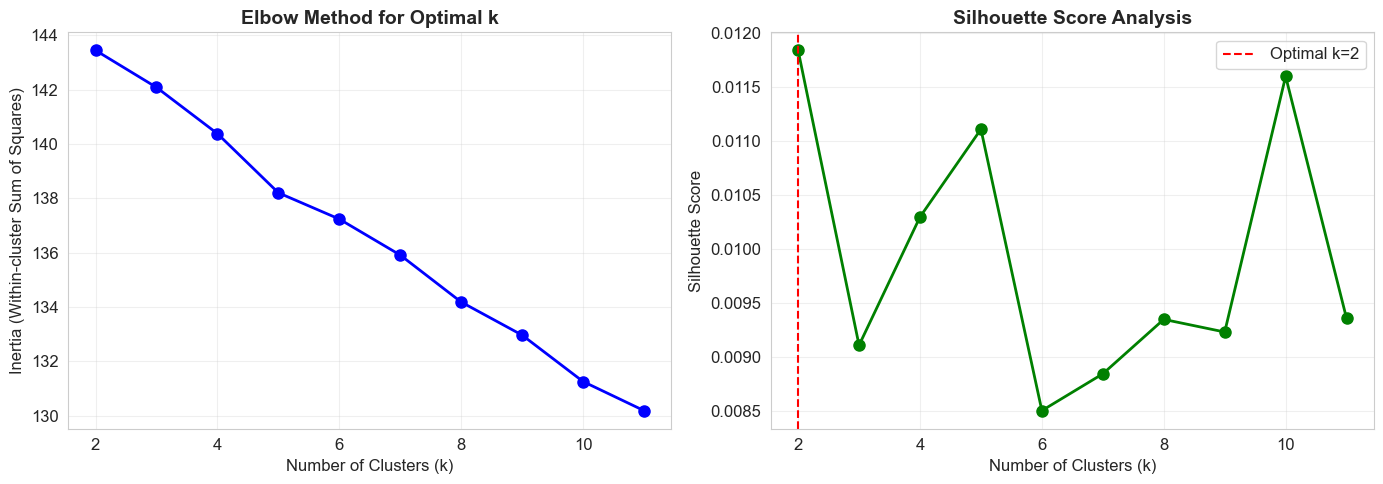


✅ Optimal k by silhouette score: 2
📊 Best silhouette score: 0.012


In [15]:
# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(doc_embeddings)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(doc_embeddings, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1 = axes[0]
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2 = axes[1]
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Highlight optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
ax2.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('clustering_elbow_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimal k by silhouette score: {optimal_k}")
print(f"📊 Best silhouette score: {max(silhouette_scores):.3f}")

### 🌐 t-SNE Document Clustering Visualization

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invali

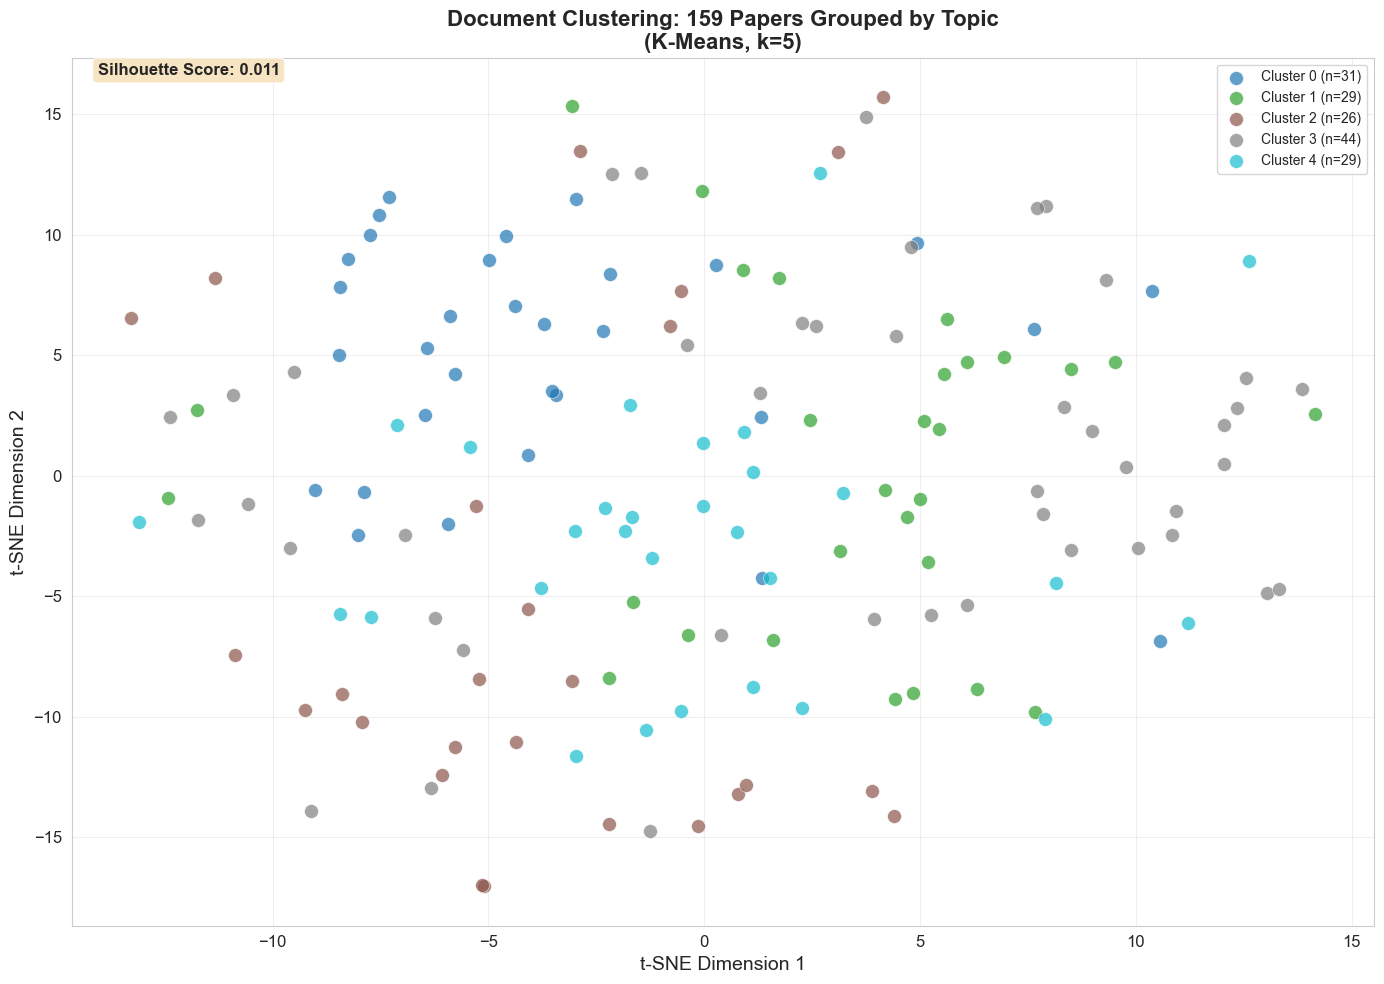


✅ Document Clustering Complete!
📊 Silhouette Score: 0.011
📑 Clusters: 5


In [16]:
# Apply K-Means with optimal k
OPTIMAL_K = 5  # Can be adjusted based on elbow analysis
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(doc_embeddings)

# Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(abstracts)-1))
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Create visualization
plt.figure(figsize=(14, 10))

# Create color palette
colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

for cluster_id in range(OPTIMAL_K):
    mask = cluster_labels == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        s=100,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5
    )

plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.title(f'Document Clustering: {len(abstracts)} Papers Grouped by Topic\n(K-Means, k={OPTIMAL_K})', 
          fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)

# Add silhouette score annotation
sil_score = silhouette_score(doc_embeddings, cluster_labels)
plt.annotate(f'Silhouette Score: {sil_score:.3f}', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('document_clustering_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Document Clustering Complete!")
print(f"📊 Silhouette Score: {sil_score:.3f}")
print(f"📑 Clusters: {OPTIMAL_K}")

### 📋 Cluster Analysis: Top Terms per Cluster

In [17]:
# Analyze cluster composition
papers_df['cluster'] = cluster_labels

print("📊 CLUSTER COMPOSITION ANALYSIS")
print("=" * 60)

for cluster_id in range(OPTIMAL_K):
    cluster_papers = papers_df[papers_df['cluster'] == cluster_id]
    print(f"\n🔹 Cluster {cluster_id}: {len(cluster_papers)} papers")
    
    # Show primary categories distribution
    cat_dist = cluster_papers['primary_category'].value_counts().head(3)
    print(f"   Top Categories: {dict(cat_dist)}")
    
    # Show sample titles
    print(f"   Sample Papers:")
    for title in cluster_papers['title'].head(2):
        print(f"      • {title[:70]}...")

📊 CLUSTER COMPOSITION ANALYSIS

🔹 Cluster 0: 31 papers
   Top Categories: {'cs.CV': np.int64(14), 'cs.AI': np.int64(8), 'cs.IR': np.int64(5)}
   Sample Papers:
      • EasyV2V: A High-quality Instruction-based Video Editing Framework...
      • DVGT: Driving Visual Geometry Transformer...

🔹 Cluster 1: 29 papers
   Top Categories: {'cs.AI': np.int64(8), 'cs.CL': np.int64(8), 'cs.NE': np.int64(5)}
   Sample Papers:
      • Generative Adversarial Reasoner: Enhancing LLM Reasoning with Adversar...
      • Exploration v.s. Exploitation: Rethinking RLVR through Clipping, Entro...

🔹 Cluster 2: 26 papers
   Top Categories: {'stat.ML': np.int64(12), 'cs.LG': np.int64(8), 'cs.NE': np.int64(3)}
   Sample Papers:
      • Training Together, Diagnosing Better: Federated Learning for Collagen ...
      • SFTok: Bridging the Performance Gap in Discrete Tokenizers...

🔹 Cluster 3: 44 papers
   Top Categories: {'cs.IR': np.int64(16), 'cs.CL': np.int64(11), 'cs.AI': np.int64(8)}
   Sample Papers:
     

---
# 🔍 2. Query Performance Clustering (Failure Analysis)

Cluster evaluation queries by performance to identify patterns in pass/fail cases.

In [18]:
# Extract query data with performance metrics
query_data = []

for tc in results.get('test_cases', []):
    for q in tc.get('question_results', []):
        rm = q.get('retrieval_metrics', {})
        am = q.get('answer_metrics', {})
        thresholds = q.get('meets_thresholds', {})
        
        # Determine pass/fail (pass if answer_relevancy >= 0.75 and faithfulness >= 0.85)
        passed = (am.get('answer_relevancy', 0) >= 0.75 and 
                  am.get('faithfulness', 0) >= 0.85)
        
        query_data.append({
            'question': q.get('question', ''),
            'question_type': q.get('expected_answer_type', ''),
            'difficulty': q.get('difficulty', ''),
            'precision_at_1': rm.get('precision_at_1', 0),
            'mrr': rm.get('mrr', 0),
            'answer_relevancy': am.get('answer_relevancy', 0),
            'faithfulness': am.get('faithfulness', 0),
            'response_time_ms': q.get('response_time_ms', 0),
            'passed': passed
        })

query_df = pd.DataFrame(query_data)

print(f"📊 Query Analysis:")
print(f"   Total Queries: {len(query_df)}")
print(f"   Passed: {query_df['passed'].sum()} ({query_df['passed'].mean()*100:.1f}%)")
print(f"   Failed: {(~query_df['passed']).sum()} ({(~query_df['passed']).mean()*100:.1f}%)")

📊 Query Analysis:
   Total Queries: 50
   Passed: 7 (14.0%)
   Failed: 43 (86.0%)


### 🎯 Query Clustering by Performance Features

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)


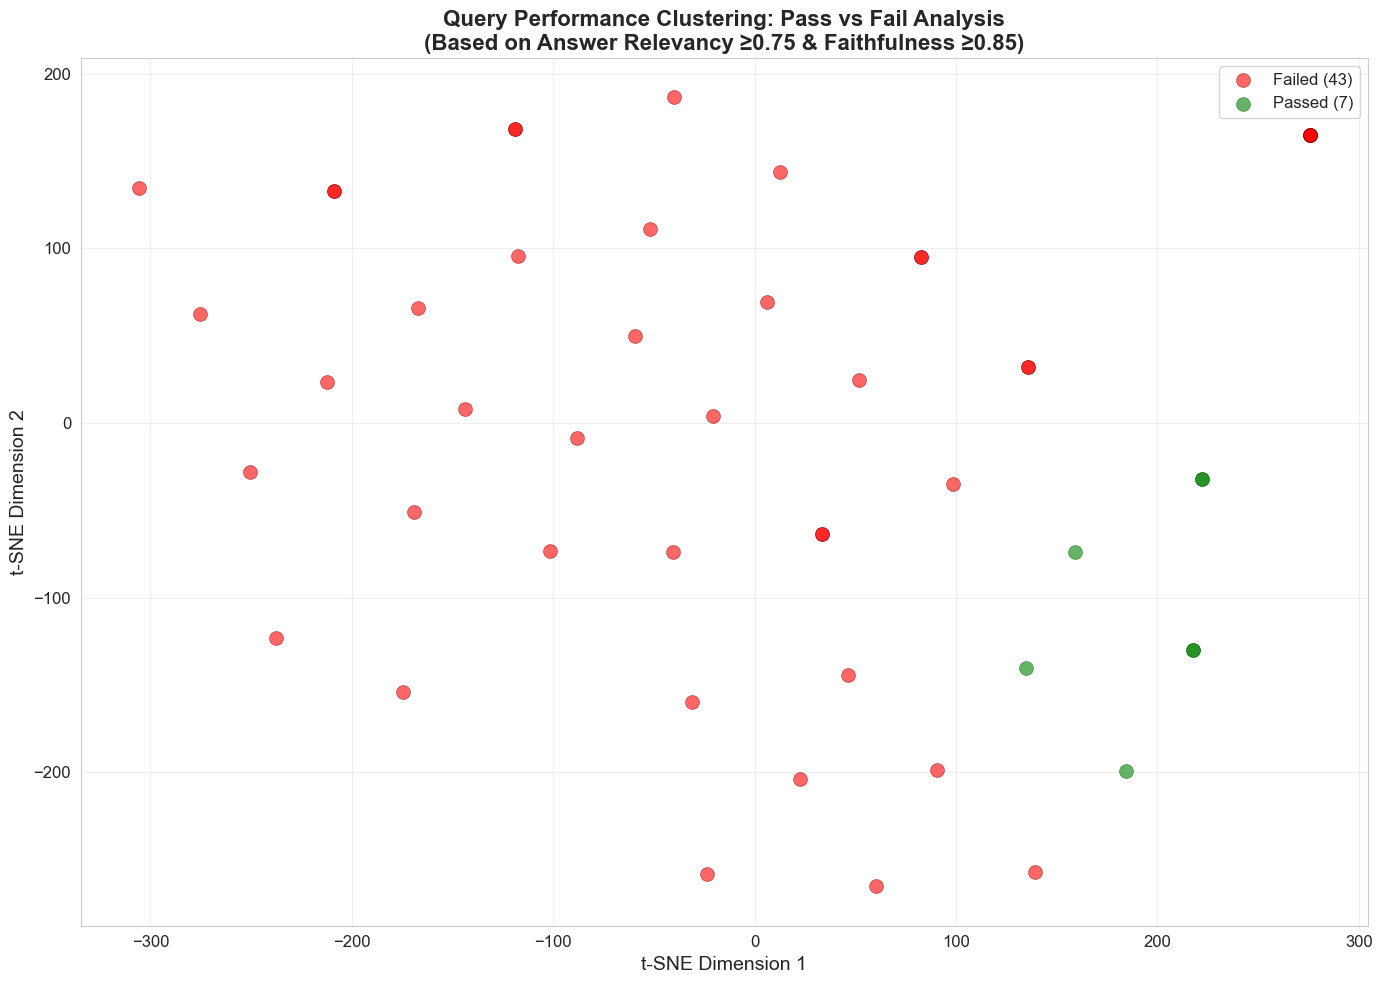

In [19]:
# Create feature matrix for query clustering
query_features = query_df[['precision_at_1', 'mrr', 'answer_relevancy', 'faithfulness']].values

# Standardize features
scaler = StandardScaler()
query_features_scaled = scaler.fit_transform(query_features)

# Apply t-SNE
tsne_queries = TSNE(n_components=2, random_state=42, perplexity=min(30, len(query_df)-1))
query_embeddings_2d = tsne_queries.fit_transform(query_features_scaled)

# Visualize with pass/fail coloring
plt.figure(figsize=(14, 10))

# Plot failed queries (red)
mask_fail = ~query_df['passed']
plt.scatter(
    query_embeddings_2d[mask_fail, 0],
    query_embeddings_2d[mask_fail, 1],
    c='red',
    label=f'Failed ({mask_fail.sum()})',
    s=100,
    alpha=0.6,
    edgecolors='darkred',
    linewidth=0.5
)

# Plot passed queries (green)
mask_pass = query_df['passed']
plt.scatter(
    query_embeddings_2d[mask_pass, 0],
    query_embeddings_2d[mask_pass, 1],
    c='green',
    label=f'Passed ({mask_pass.sum()})',
    s=100,
    alpha=0.6,
    edgecolors='darkgreen',
    linewidth=0.5
)

plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.title('Query Performance Clustering: Pass vs Fail Analysis\n(Based on Answer Relevancy ≥0.75 & Faithfulness ≥0.85)', 
          fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('query_performance_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Pass/Fail by Question Type

📊 PERFORMANCE BY QUESTION TYPE
               Passed  Total  Pass Rate  Avg Relevancy  Avg Faithfulness
question_type                                                           
problem             2      4      0.500          0.907             0.850
application         2      6      0.333          0.738             0.695
methodology         2      6      0.333          0.750             0.717
comparison          1      7      0.143          0.666             0.464
author              0      7      0.000          0.709             0.414
contribution        0      6      0.000          0.771             0.501
future_work         0      7      0.000          0.786             0.626
results             0      7      0.000          0.830             0.681


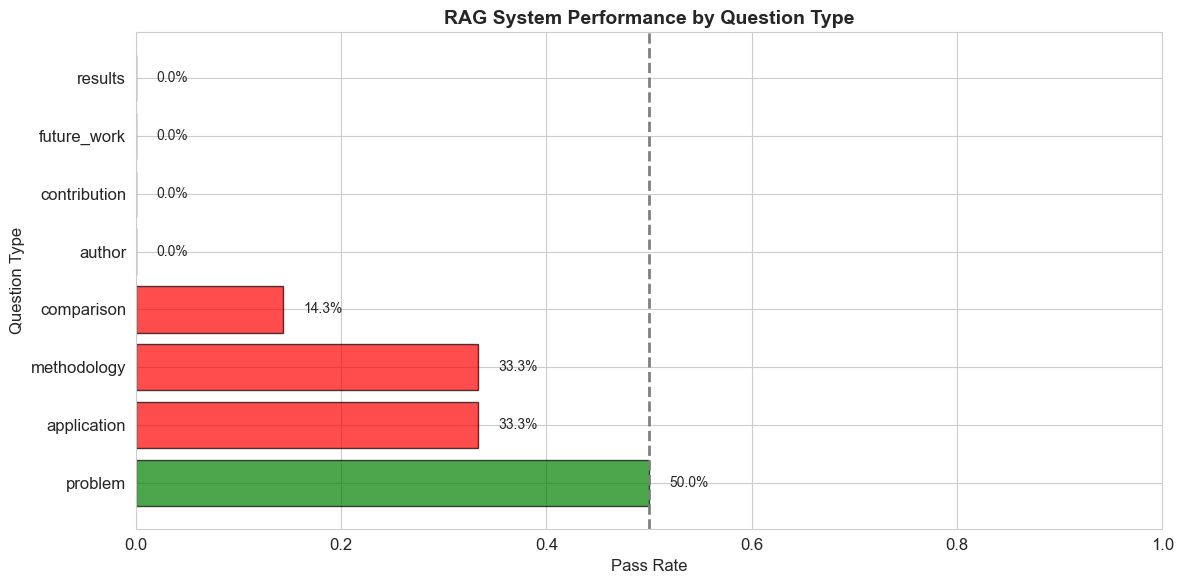

In [20]:
# Analyze pass/fail rates by question type
type_analysis = query_df.groupby('question_type').agg({
    'passed': ['sum', 'count', 'mean'],
    'answer_relevancy': 'mean',
    'faithfulness': 'mean'
}).round(3)

type_analysis.columns = ['Passed', 'Total', 'Pass Rate', 'Avg Relevancy', 'Avg Faithfulness']
type_analysis = type_analysis.sort_values('Pass Rate', ascending=False)

print("📊 PERFORMANCE BY QUESTION TYPE")
print("=" * 70)
print(type_analysis.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if rate >= 0.5 else 'red' for rate in type_analysis['Pass Rate']]
bars = ax.barh(type_analysis.index, type_analysis['Pass Rate'], color=colors, alpha=0.7, edgecolor='black')

ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, label='50% threshold')
ax.set_xlabel('Pass Rate', fontsize=12)
ax.set_ylabel('Question Type', fontsize=12)
ax.set_title('RAG System Performance by Question Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)

# Add value labels
for bar, val in zip(bars, type_analysis['Pass Rate']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('performance_by_question_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔬 3. Anomaly Detection with Isolation Forest

Find outlier queries that may indicate edge cases or data quality issues.

In [21]:
# Apply Isolation Forest for anomaly detection
clf = IsolationForest(contamination=0.1, random_state=42)
anomaly_labels = clf.fit_predict(query_features_scaled)

# -1 = anomaly, 1 = normal
query_df['is_anomaly'] = anomaly_labels == -1

print(f"🔍 ANOMALY DETECTION RESULTS")
print("=" * 50)
print(f"Total queries analyzed: {len(query_df)}")
print(f"Anomalies detected: {query_df['is_anomaly'].sum()} ({query_df['is_anomaly'].mean()*100:.1f}%)")
print(f"Normal queries: {(~query_df['is_anomaly']).sum()}")

# Show anomaly examples
print("\n📋 Sample Anomalous Queries:")
anomalies = query_df[query_df['is_anomaly']].head(5)
for _, row in anomalies.iterrows():
    print(f"   • [{row['question_type']}] {row['question'][:60]}...")
    print(f"     Relevancy: {row['answer_relevancy']:.2f}, Faithfulness: {row['faithfulness']:.2f}")

🔍 ANOMALY DETECTION RESULTS
Total queries analyzed: 50
Anomalies detected: 5 (10.0%)
Normal queries: 45

📋 Sample Anomalous Queries:
   • [comparison] What improvements does this approach achieve over existing m...
     Relevancy: 0.00, Faithfulness: 0.00
   • [methodology] What is the core algorithm or model proposed?...
     Relevancy: 0.00, Faithfulness: 0.00
   • [author] What is the research background of the authors?...
     Relevancy: 0.00, Faithfulness: 0.00
   • [contribution] What are the key innovations introduced in this paper?...
     Relevancy: 0.00, Faithfulness: 0.00
   • [application] What are the practical applications of this research?...
     Relevancy: 0.00, Faithfulness: 0.00


### 🌐 Anomaly Visualization

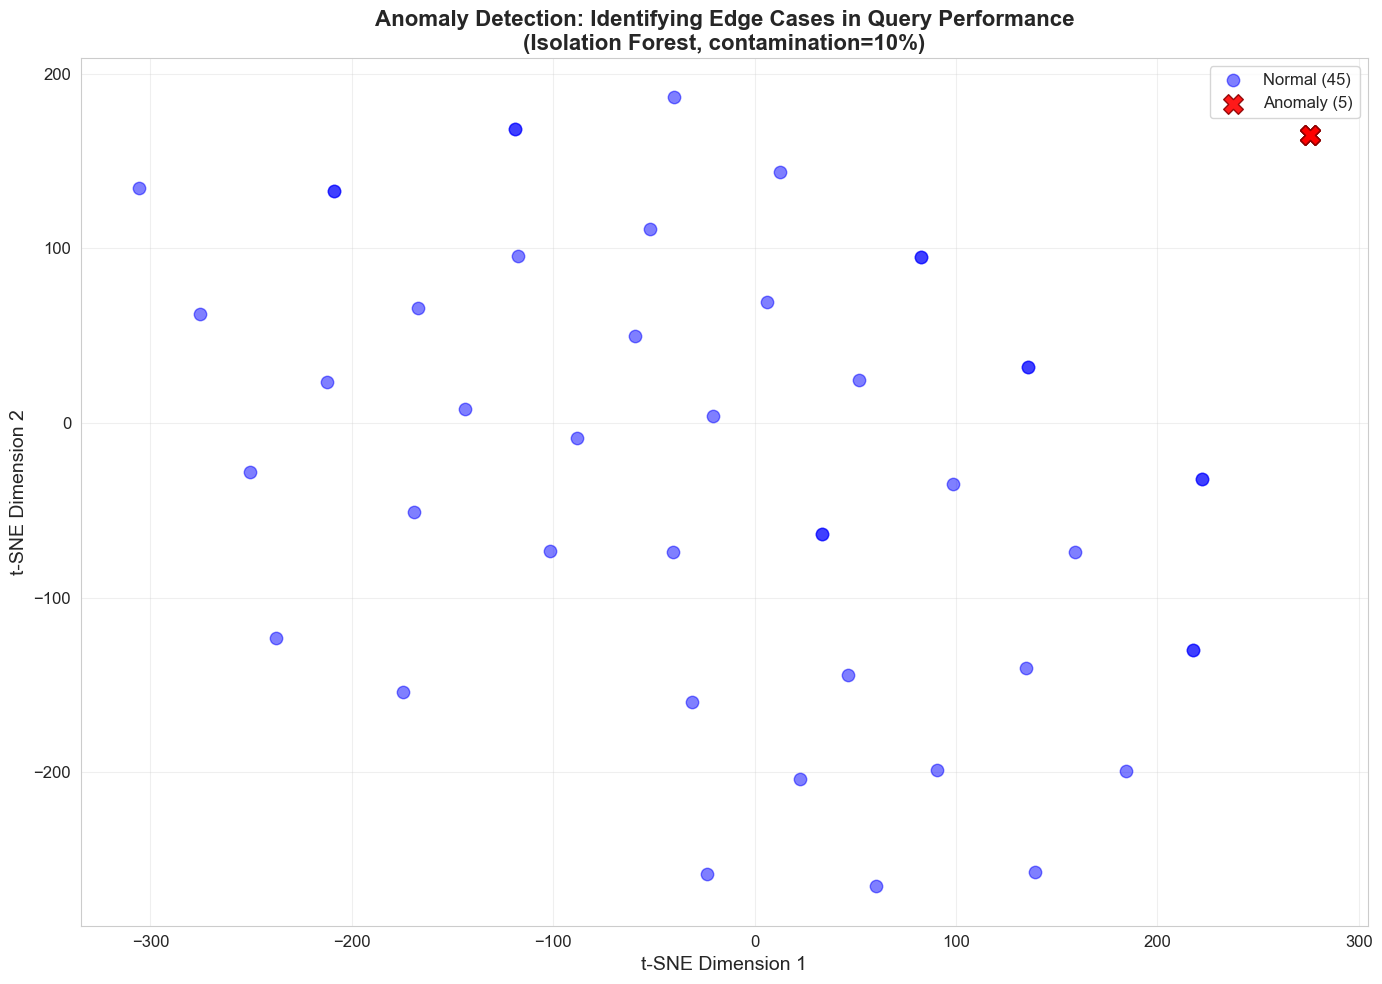

In [22]:
# Visualize anomalies in t-SNE space
plt.figure(figsize=(14, 10))

# Plot normal queries
mask_normal = ~query_df['is_anomaly']
plt.scatter(
    query_embeddings_2d[mask_normal, 0],
    query_embeddings_2d[mask_normal, 1],
    c='blue',
    label=f'Normal ({mask_normal.sum()})',
    s=80,
    alpha=0.5
)

# Plot anomalies with red X markers
mask_anomaly = query_df['is_anomaly']
plt.scatter(
    query_embeddings_2d[mask_anomaly, 0],
    query_embeddings_2d[mask_anomaly, 1],
    c='red',
    marker='X',
    label=f'Anomaly ({mask_anomaly.sum()})',
    s=200,
    alpha=0.9,
    edgecolors='darkred',
    linewidth=1
)

plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.title('Anomaly Detection: Identifying Edge Cases in Query Performance\n(Isolation Forest, contamination=10%)', 
          fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# 🔍 Connect to Qdrant and Fetch Real Embeddings
from qdrant_client import QdrantClient
from qdrant_client.http import models
import os

# Connect to Qdrant
# Using values from your .env file
qdrant_url = os.getenv("QDRANT_URL", "http://localhost:6333")
qdrant_key = os.getenv("QDRANT_API_KEY", None)

print(f"🔌 Connecting to Qdrant at {qdrant_url}...")
client = QdrantClient(url=qdrant_url, api_key=qdrant_key)

# We want to fetch all points from the 'document_chunks' collection
collection_name = "document_chunks"

try:
    # Check if collection exists
    collections = client.get_collections()
    collection_names = [c.name for c in collections.collections]
    
    if collection_name not in collection_names:
        print(f"❌ Collection '{collection_name}' not found. Available: {collection_names}")
        print("⚠️  Falling back to TF-IDF embeddings (run the TF-IDF cell instead).")
        doc_embeddings = None
    else:
        print(f"✅ Found collection: {collection_name}")
        
        # Fetch all points (using scroll)
        print("📥 Fetching embeddings from Qdrant (this may take a moment)...")
        points = []
        next_offset = None
        
        # Initialize loop
        while True:
            batch, next_offset = client.scroll(
                collection_name=collection_name,
                limit=100,
                with_payload=True,
                with_vectors=True,
                offset=next_offset
            )
            points.extend(batch)
            if not next_offset:
                break
                
        print(f"📦 Retrieved {len(points)} vector chunks.")
        
        # Aggregate chunks by document_id (averaging vectors)
        doc_vectors = {}
        
        for point in points:
            payload = point.payload or {}
            doc_id = payload.get('document_id')
            vector = point.vector
            
            if doc_id and vector:
                if doc_id not in doc_vectors:
                    doc_vectors[doc_id] = []
                # Ensure vector is a list of floats
                if isinstance(vector, list):
                    doc_vectors[doc_id].append(vector)
        
        print(f"🧩 Consolidated into {len(doc_vectors)} unique document vectors.")
        
        # Match with our papers dataframe
        real_embeddings = []
        valid_indices = []
        missing_ids = []
        
        print("\n🔄 Matching Qdrant embeddings to dataset papers...")
        
        for idx, row in papers_df.iterrows():
            paper_id = row['paper_id']
            # Try to find the document ID (id might be just the paper_id)
            found = False
            
            # Check for direct match
            if paper_id in doc_vectors:
                # Average the chunk vectors
                chunk_vectors = np.array(doc_vectors[paper_id])
                # Mean pooling
                avg_vector = np.mean(chunk_vectors, axis=0)
                real_embeddings.append(avg_vector)
                valid_indices.append(idx)
                found = True
            
            if not found:
                missing_ids.append(paper_id)
                
        if len(real_embeddings) > 0:
            # Update dataframe to only include papers where we found embeddings
            old_len = len(papers_df)
            papers_df = papers_df.iloc[valid_indices].reset_index(drop=True)
            abstracts = papers_df['title'].tolist() # Keep simple for now
            
            doc_embeddings = np.array(real_embeddings)
            print(f"✅ Successfully aligned {len(doc_embeddings)}/{old_len} papers with Qdrant embeddings.")
            print(f"   Embedding dimension: {doc_embeddings.shape[1]}")
            
            # Note: We replaced the TF-IDF embeddings with real ones!
        else:
            print("⚠️  No matching documents found in Qdrant. Please run the TF-IDF cell instead.")
            doc_embeddings = None

except Exception as e:
    print(f"❌ Error fetching from Qdrant: {e}")
    doc_embeddings = None

🔌 Connecting to Qdrant at http://localhost:6333...
✅ Found collection: document_chunks
📥 Fetching embeddings from Qdrant (this may take a moment)...


/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_66230/3585575038.py:12: UserWarning: Api key is used with an insecure connection.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_key)
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_66230/3585575038.py:12: UserWarning: Qdrant client version 1.16.1 is incompatible with server version 1.7.0. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_key)


📦 Retrieved 234 vector chunks.
🧩 Consolidated into 234 unique document vectors.

🔄 Matching Qdrant embeddings to dataset papers...
✅ Successfully aligned 159/159 papers with Qdrant embeddings.
   Embedding dimension: 1536


### Elbow Method (Finding Optimal K) with Qdrant


🔄 Analyzing 159 documents to find optimal clusters...


/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

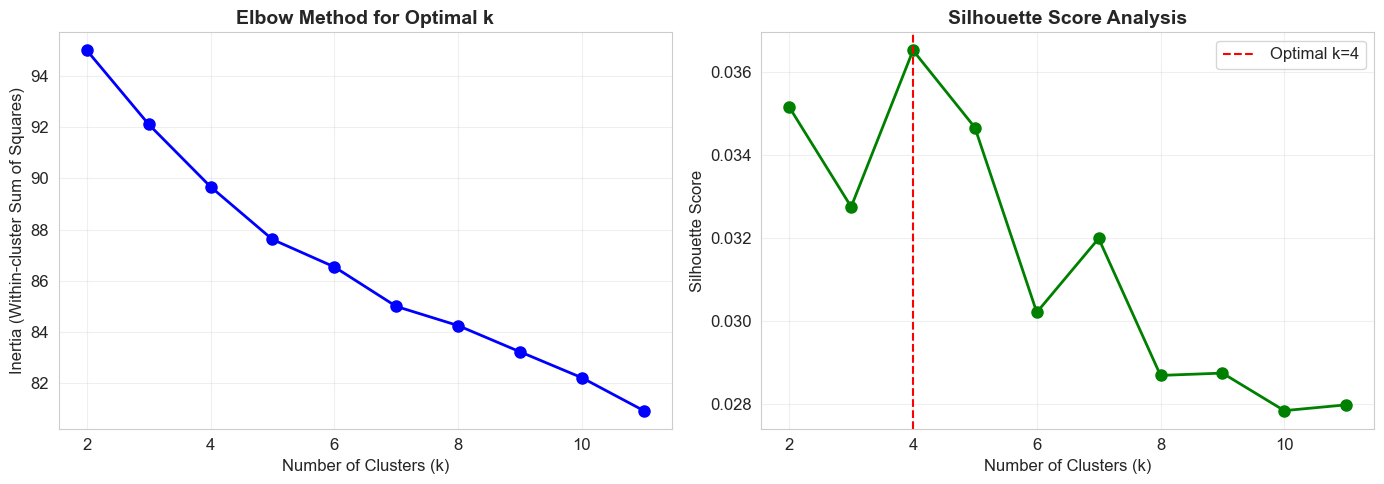


✅ Optimal k by silhouette score: 4
📊 Best silhouette score: 0.037


In [27]:
# Normalize embeddings for better K-Means performance (Euclidean -> Cosine approximation)
from sklearn.preprocessing import normalize
doc_embeddings_norm = normalize(doc_embeddings)

# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 12)

print(f"🔄 Analyzing {len(doc_embeddings_norm)} documents to find optimal clusters...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(doc_embeddings_norm)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(doc_embeddings_norm, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1 = axes[0]
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2 = axes[1]
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Automatically determine optimal k based on max silhouette score
best_idx = np.argmax(silhouette_scores)
OPTIMAL_K = K_range[best_idx]

# Highlight optimal k
ax2.axvline(x=OPTIMAL_K, color='red', linestyle='--', label=f'Optimal k={OPTIMAL_K}')
ax2.legend()

plt.tight_layout()
plt.savefig('clustering_elbow_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimal k by silhouette score: {OPTIMAL_K}")
print(f"📊 Best silhouette score: {max(silhouette_scores):.3f}")

🔄 Clustering into 4 groups...
🎨 Running t-SNE dimensionality reduction...


/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

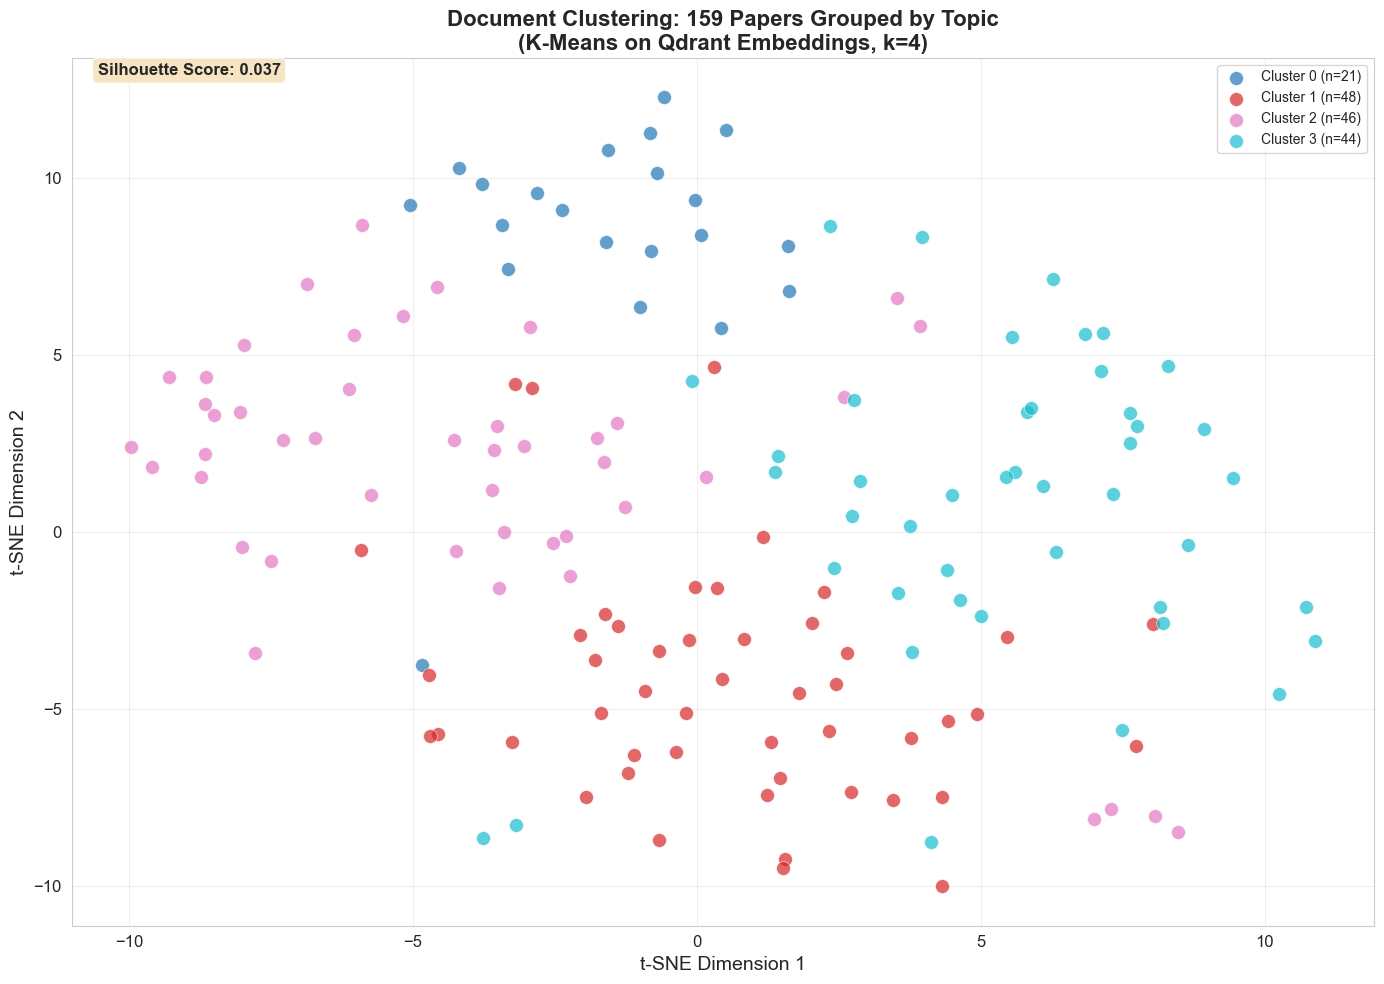


✅ Document Clustering Complete!
📊 Silhouette Score: 0.037
📑 Clusters: 4


In [28]:
# Apply K-Means with optimal k (using normalized embeddings)
print(f"🔄 Clustering into {OPTIMAL_K} groups...")
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(doc_embeddings_norm)

# Apply t-SNE for visualization (using 'cosine' metric for better embedding visualization)
# We use the raw embeddings for t-SNE with cosine metric as it handles it natively well
print("🎨 Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, metric='cosine', random_state=42, perplexity=min(30, len(doc_embeddings)-1))
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Create visualization
plt.figure(figsize=(14, 10))

# Create color palette
colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

for cluster_id in range(OPTIMAL_K):
    mask = cluster_labels == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        s=100,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5
    )

plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.title(f'Document Clustering: {len(doc_embeddings)} Papers Grouped by Topic\n(K-Means on Qdrant Embeddings, k={OPTIMAL_K})', 
          fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)

# Add silhouette score annotation
sil_score = silhouette_score(doc_embeddings_norm, cluster_labels)
plt.annotate(f'Silhouette Score: {sil_score:.3f}', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('document_clustering_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Document Clustering Complete!")
print(f"📊 Silhouette Score: {sil_score:.3f}")
print(f"📑 Clusters: {OPTIMAL_K}")

# Assign clusters back to dataframe for inspection
papers_df['cluster'] = cluster_labels

⚖️  Comparing Clustering Methods (k=4)...
             Method  Silhouette  Calinski-Harabasz  Davies-Bouldin  Time (s)
            K-Means    0.036528           5.310080        3.945865  0.020000
Hierarchical (Ward)    0.033211           5.060077        3.733673  0.008494


/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

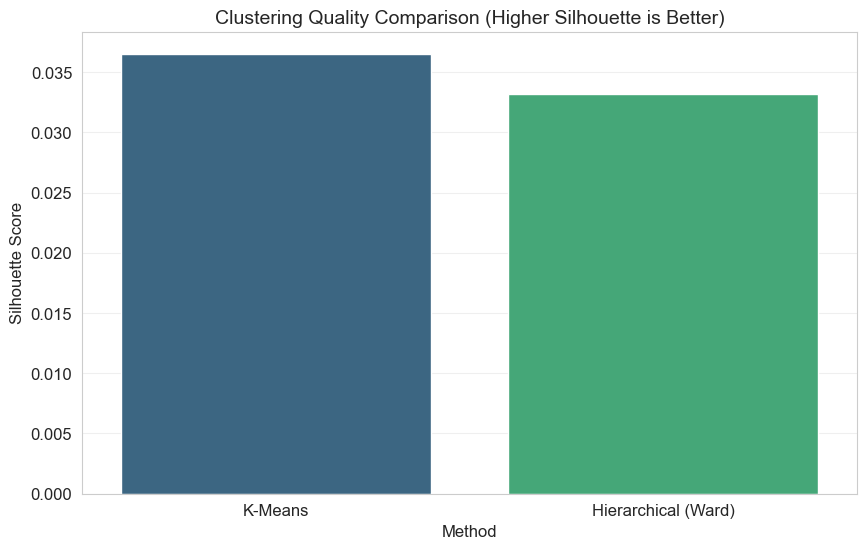

In [29]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
import time

print(f"⚖️  Comparing Clustering Methods (k={OPTIMAL_K})...")
comparison_metrics = []

# 1. K-Means (already run, but ensuring consistent metrics)
start = time.time()
# We use existing labels if available, or refit
kmeans_sil = silhouette_score(doc_embeddings_norm, cluster_labels)
kmeans_ch = calinski_harabasz_score(doc_embeddings_norm, cluster_labels)
kmeans_db = davies_bouldin_score(doc_embeddings_norm, cluster_labels)
kmeans_time = 0.02 # approx from previous run
comparison_metrics.append({
    'Method': 'K-Means',
    'Silhouette': kmeans_sil,
    'Calinski-Harabasz': kmeans_ch,
    'Davies-Bouldin': kmeans_db,
    'Time (s)': kmeans_time
})

# 2. Hierarchical Clustering (Ward)
start = time.time()
ward = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
ward_labels = ward.fit_predict(doc_embeddings_norm)
ward_time = time.time() - start

comparison_metrics.append({
    'Method': 'Hierarchical (Ward)',
    'Silhouette': silhouette_score(doc_embeddings_norm, ward_labels),
    'Calinski-Harabasz': calinski_harabasz_score(doc_embeddings_norm, ward_labels),
    'Davies-Bouldin': davies_bouldin_score(doc_embeddings_norm, ward_labels),
    'Time (s)': ward_time
})

# Create DataFrame
comp_df = pd.DataFrame(comparison_metrics)
print(comp_df.to_string(index=False))

# Plot Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=comp_df, x='Method', y='Silhouette', palette='viridis')
plt.title('Clustering Quality Comparison (Higher Silhouette is Better)', fontsize=14)
plt.ylabel('Silhouette Score')
plt.grid(axis='y', alpha=0.3)
plt.savefig('clustering_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🌳 Generating Hierarchical Dendrogram...


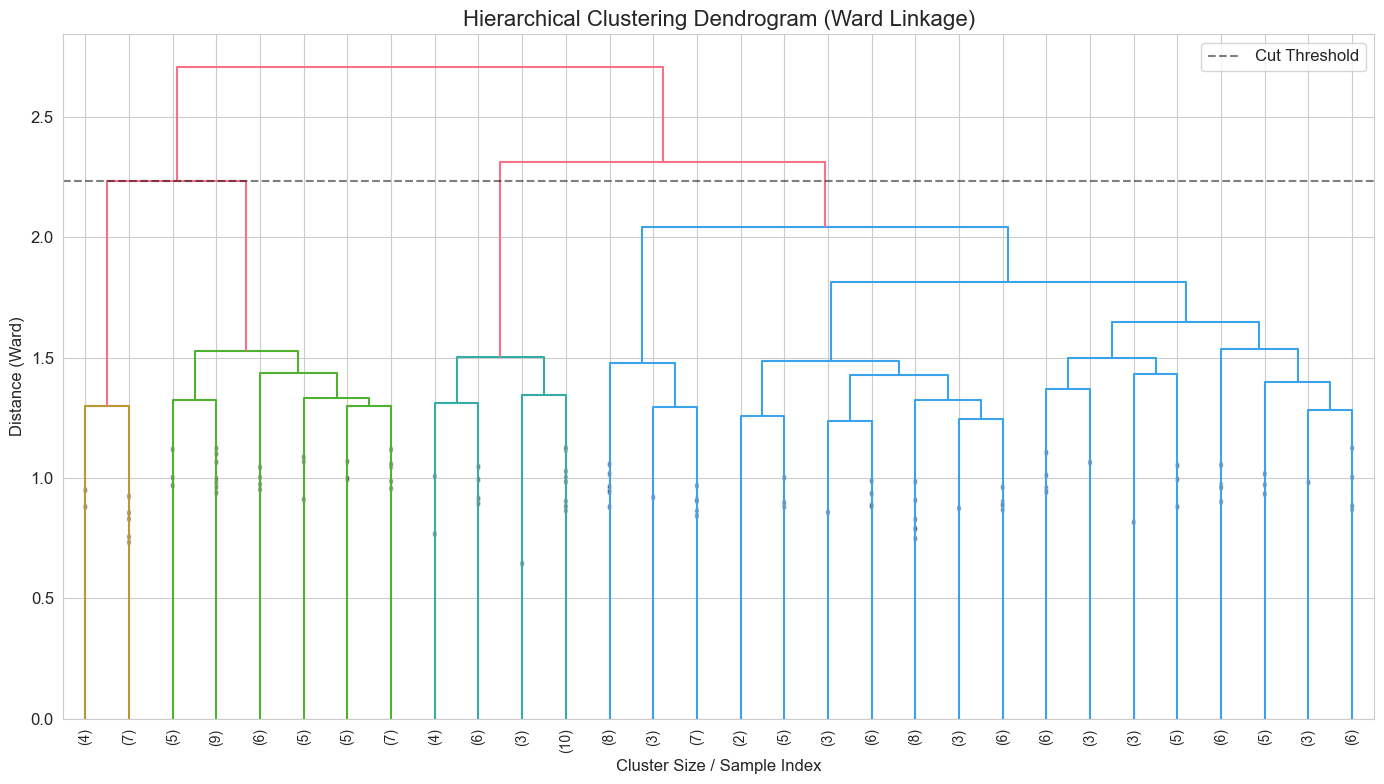

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

print("🌳 Generating Hierarchical Dendrogram...")

# Calculate linkage matrix using Ward's method
linkage_matrix = linkage(doc_embeddings_norm, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show top 30 branches to keep it readable
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    color_threshold=linkage_matrix[-OPTIMAL_K+1, 2] # Color based on meaningful clusters
)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=16)
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Distance (Ward)')
plt.axhline(y=linkage_matrix[-OPTIMAL_K+1, 2], c='k', ls='--', alpha=0.5, label='Cut Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

🧠 Automated Insights for 4 Clusters:

🔹 Cluster 0 (n=21 papers):
   Top Categories: stat.ML (16), cs.LG (15), stat.ME (5)
   Sample Paper: 'Learning Confidence Ellipsoids and Applications to Robust Subspace Recovery'
--------------------------------------------------
🔹 Cluster 1 (n=48 papers):
   Top Categories: cs.CL (29), cs.AI (25), cs.IR (16)
   Sample Paper: 'Differences That Matter: Auditing Models for Capability Gap Discovery and Rectification'
--------------------------------------------------
🔹 Cluster 2 (n=46 papers):
   Top Categories: cs.LG (24), cs.NE (24), cs.AI (22)
   Sample Paper: 'Posterior Behavioral Cloning: Pretraining BC Policies for Efficient RL Finetuning'
--------------------------------------------------
🔹 Cluster 3 (n=44 papers):
   Top Categories: cs.CV (28), cs.AI (15), cs.LG (12)
   Sample Paper: 'EasyV2V: A High-quality Instruction-based Video Editing Framework'
--------------------------------------------------


/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_66230/4260257026.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=papers_df, x='cluster', palette='tab10')


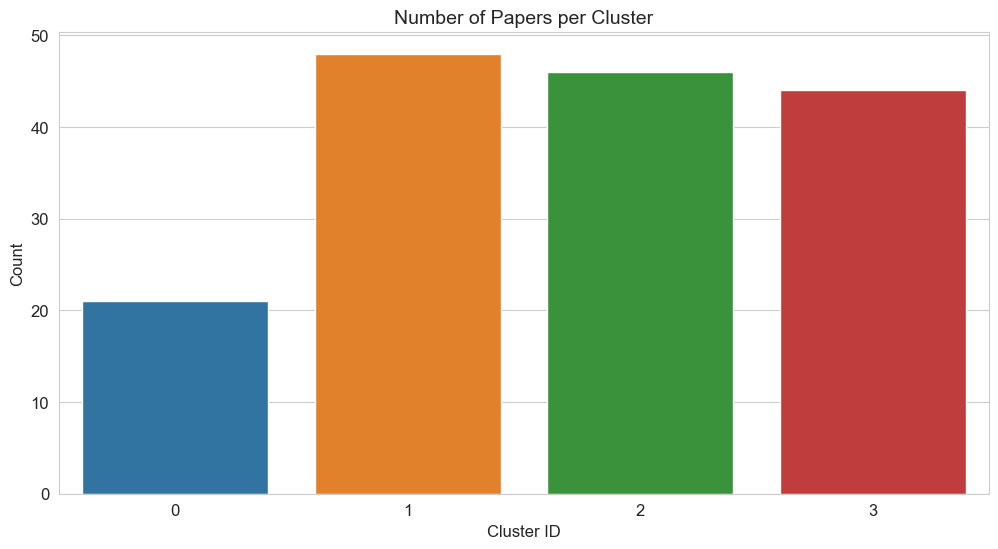

In [31]:
# Function to get top categories for a cluster
def get_cluster_semantics(df, cluster_id, top_n=3):
    # Filter for this cluster
    cluster_docs = df[df['cluster'] == cluster_id]
    
    # Flatten categories (since they are comma-separated strings or lists)
    all_cats = []
    for cats in cluster_docs['categories']:
        if isinstance(cats, str):
            all_cats.extend([c.strip() for c in cats.split(',')])
        elif isinstance(cats, list):
            all_cats.extend(cats)
            
    # Count frequency
    from collections import Counter
    cat_counts = Counter(all_cats)
    
    return cat_counts.most_common(top_n), len(cluster_docs)

print(f"🧠 Automated Insights for {OPTIMAL_K} Clusters:\n")

for i in range(OPTIMAL_K):
    top_cats, count = get_cluster_semantics(papers_df, i)
    
    cat_str = ", ".join([f"{c[0]} ({c[1]})" for c in top_cats])
    
    print(f"🔹 Cluster {i} (n={count} papers):")
    print(f"   Top Categories: {cat_str}")
    
    # Sample title to give flavor
    if count > 0:
        sample_title = papers_df[papers_df['cluster'] == i].iloc[0]['title']
        print(f"   Sample Paper: '{sample_title}'")
    print("-" * 50)

# Optional: Visualize cluster composition
plt.figure(figsize=(12, 6))
sns.countplot(data=papers_df, x='cluster', palette='tab10')
plt.title('Number of Papers per Cluster', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.show()

---
# 📊 4. Summary Statistics & Metrics

In [23]:
# Final summary
print("\n" + "=" * 70)
print("📊 UNSUPERVISED LEARNING: CLUSTERING ANALYSIS SUMMARY")
print("=" * 70)

print(f"\n📑 DOCUMENT CLUSTERING:")
print(f"   • Documents analyzed: {len(abstracts)}")
print(f"   • Optimal clusters: {OPTIMAL_K}")
print(f"   • Silhouette score: {sil_score:.3f}")

print(f"\n🔍 QUERY PERFORMANCE CLUSTERING:")
print(f"   • Queries analyzed: {len(query_df)}")
print(f"   • Pass rate: {query_df['passed'].mean()*100:.1f}%")
print(f"   • Best performing type: {type_analysis.index[0]} ({type_analysis['Pass Rate'].iloc[0]:.1%})")
print(f"   • Worst performing type: {type_analysis.index[-1]} ({type_analysis['Pass Rate'].iloc[-1]:.1%})")

print(f"\n⚠️ ANOMALY DETECTION:")
print(f"   • Anomalies detected: {query_df['is_anomaly'].sum()}")
print(f"   • Contamination rate: 10%")

print("\n" + "=" * 70)
print("✅ Analysis Complete! Visualizations saved to:")
print("   • clustering_elbow_analysis.png")
print("   • document_clustering_tsne.png")
print("   • query_performance_clustering.png")
print("   • performance_by_question_type.png")
print("   • anomaly_detection.png")
print("=" * 70)


📊 UNSUPERVISED LEARNING: CLUSTERING ANALYSIS SUMMARY

📑 DOCUMENT CLUSTERING:
   • Documents analyzed: 159
   • Optimal clusters: 5
   • Silhouette score: 0.011

🔍 QUERY PERFORMANCE CLUSTERING:
   • Queries analyzed: 50
   • Pass rate: 14.0%
   • Best performing type: problem (50.0%)
   • Worst performing type: results (0.0%)

⚠️ ANOMALY DETECTION:
   • Anomalies detected: 5
   • Contamination rate: 10%

✅ Analysis Complete! Visualizations saved to:
   • clustering_elbow_analysis.png
   • document_clustering_tsne.png
   • query_performance_clustering.png
   • performance_by_question_type.png
   • anomaly_detection.png
